# P2 G1 입결 반영 최종 CSV 시각화 EDA

최종 산출물 `P2_G1_concat.csv`를 기준으로 입결 반영 상태, 결측 원인, 성적/취업/진학 변수와의 관계, 대학별 커버리지를 점검한다.


## P2 G1 입결 반영 EDA 실행 요약

- 분석 파일: `/home/sieg/projects-wsl/SBS_dataScience/workbook/p2/p2_2/final/data/P2_G1_concat.csv`
- 최종 CSV 원본 행/열: `10,242` x `17`
- EDA 작업 행/열: `10,242` x `20` (`입결_존재`, `A_minus_CD`, `취업_건보_gap` 파생)
- 입결 반영 행: `3,737` / `10,242` (`36.49%`)
- 입결 커버 대학: `157` / `227`
- 입결 미반영 행: `6,505` (`63.51%`)
- 중복 키: `0`건
- 한글 폰트: `NanumGothic`


,metric,value,note
0,rows,10242,2024 대학-학과_계열 단위
1,source_columns,17,최종 CSV 원본 컬럼 수
2,working_columns,20,EDA 파생 컬럼 포함 작업 컬럼 수
3,universities,227,전체 대학 수
4,department_labels,4195,정규화 학과 라벨 수
5,admission_non_null,3737,최종 CSV에 반영된 입결 점수 행
6,admission_missing,6505,입결 미반영 행
7,admission_covered_universities,157,입결 1개 이상 존재 대학
8,duplicate_key_rows,0,중복 키 행
9,font_used,NanumGothic,matplotlib 한글 폰트


### 주요 컬럼 결측

,column,missing_n,missing_pct,dtype
4,입결_프록시,6505,63.512986,float64
8,전체취업률,2765,26.996680,float64
9,건보가입취업률,2765,26.996680,float64
10,전체진학률,2655,25.922671,float64
16,학점포기제유무,0,0.000000,str


### 입결과 숫자형 변수의 상관

,feature,n_pair,pearson,spearman,abs_spearman
8,대학원진학률,2850,0.248398,0.301955,0.301955
0,A비율,3737,0.235223,0.299012,0.299012
5,전체진학률,2850,0.245495,0.292578,0.292578
9,국내진학률,2850,0.243240,0.290763,0.290763
11,A_minus_CD,3737,0.196591,0.265618,0.265618
1,CD비율,3737,-0.097853,-0.191413,0.191413
4,건보가입취업률,2825,0.092358,0.138451,0.138451
10,국외진학률,2850,0.087809,0.137204,0.137204
3,전체취업률,2825,0.073647,0.136589,0.136589
2,F비율,3737,-0.058082,-0.127901,0.127901


### 0커버 대학 원인

,zero_coverage_major_reason,zero_coverage_detail_reason,universities,grade_labels,raw_rows,raw_metric_nonnull
0,crawled_but_zero_coverage,fetched_but_result_tables_0,35,562,0,0
1,crawled_but_zero_coverage,metric_exists_but_department_unmatched,15,408,144,121
2,crawled_but_zero_coverage,raw_fetched_but_no_usable_metric,7,341,136,0
3,not_crawled_or_scope_excluded,not_crawled_or_scope_excluded,13,236,0,0


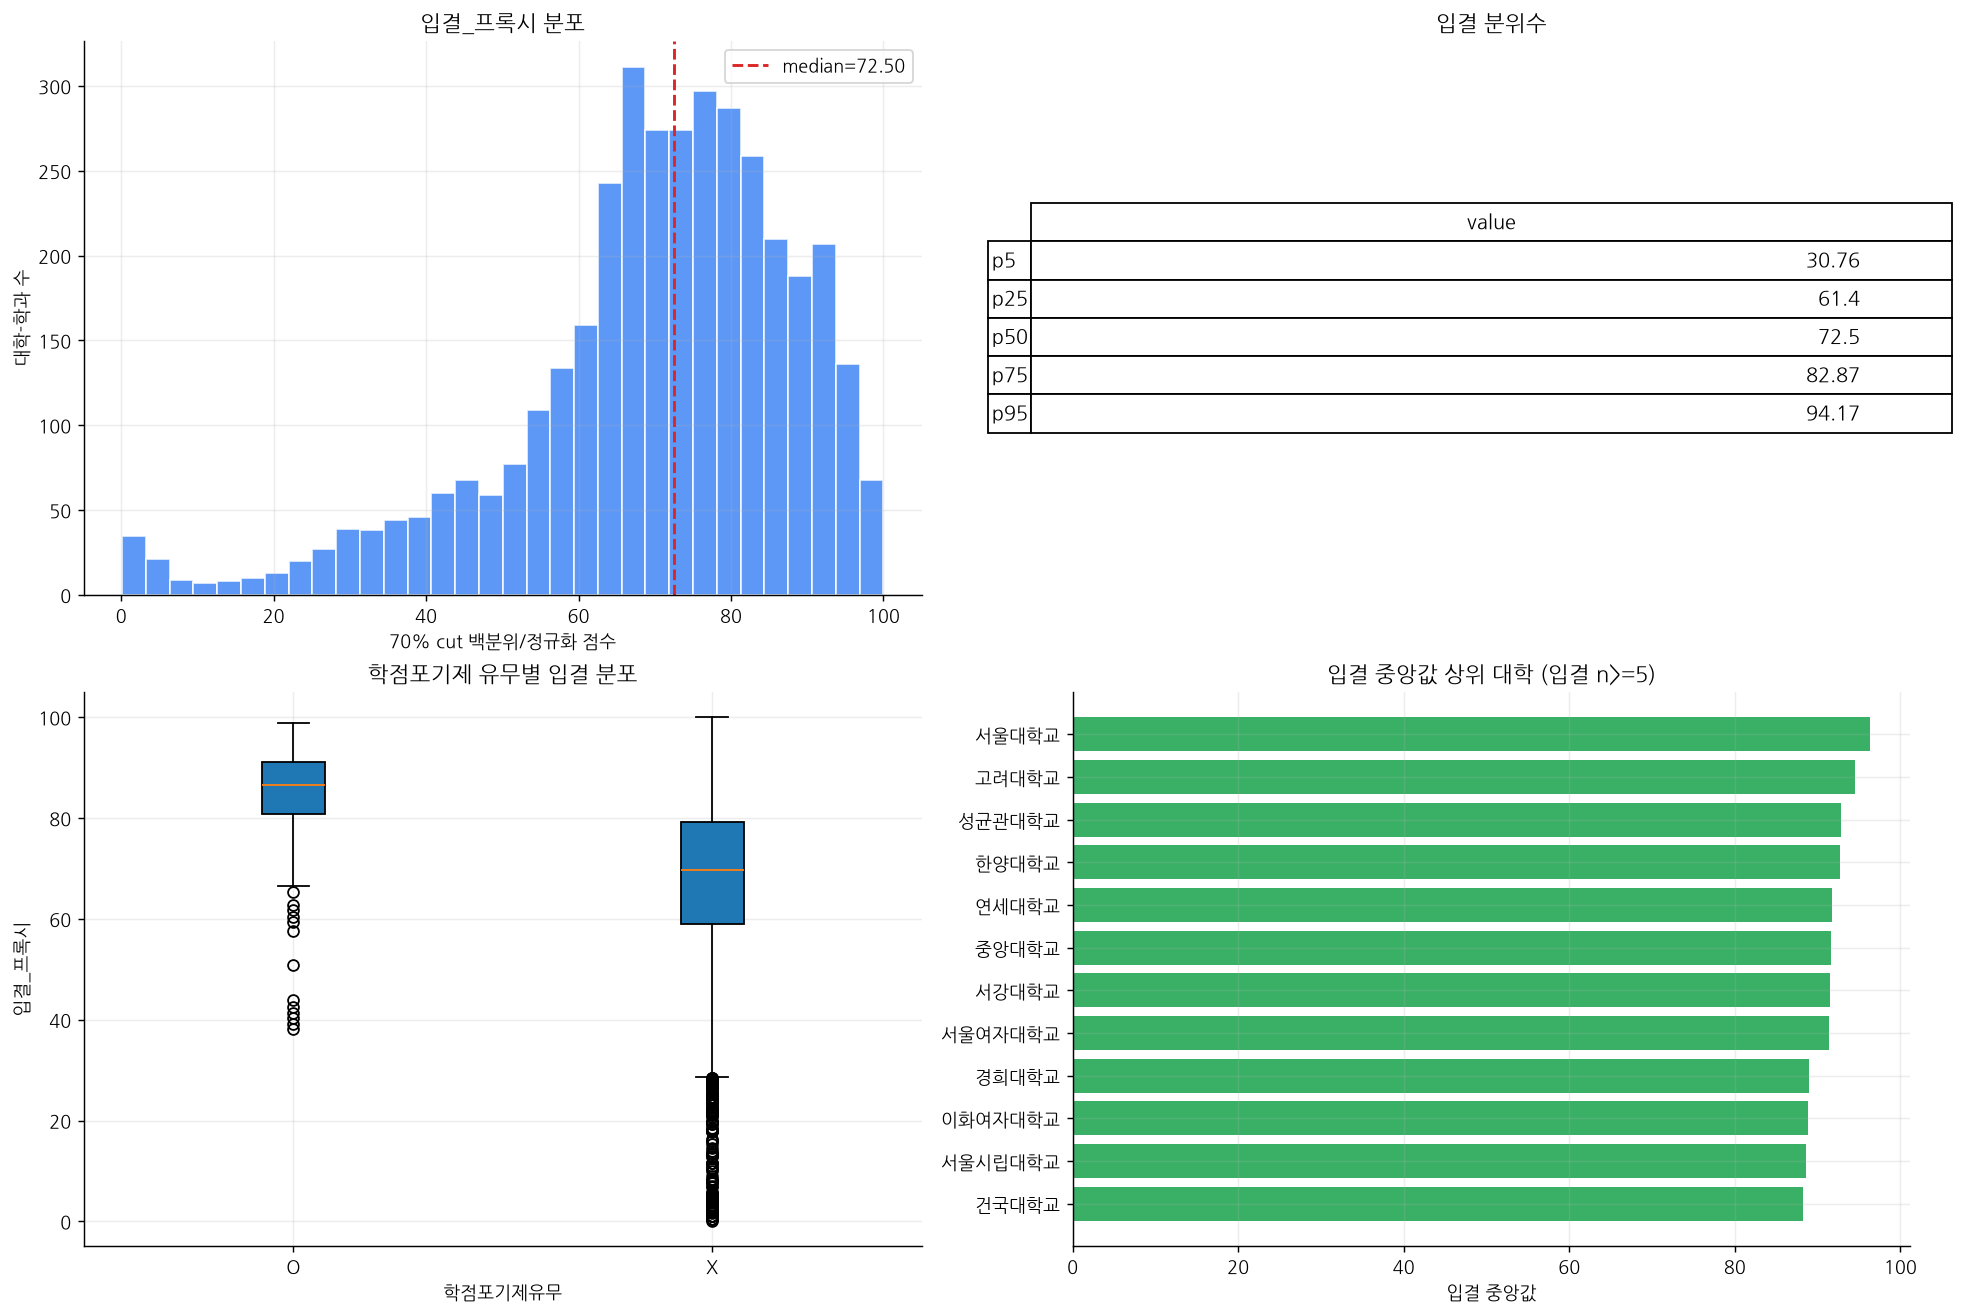

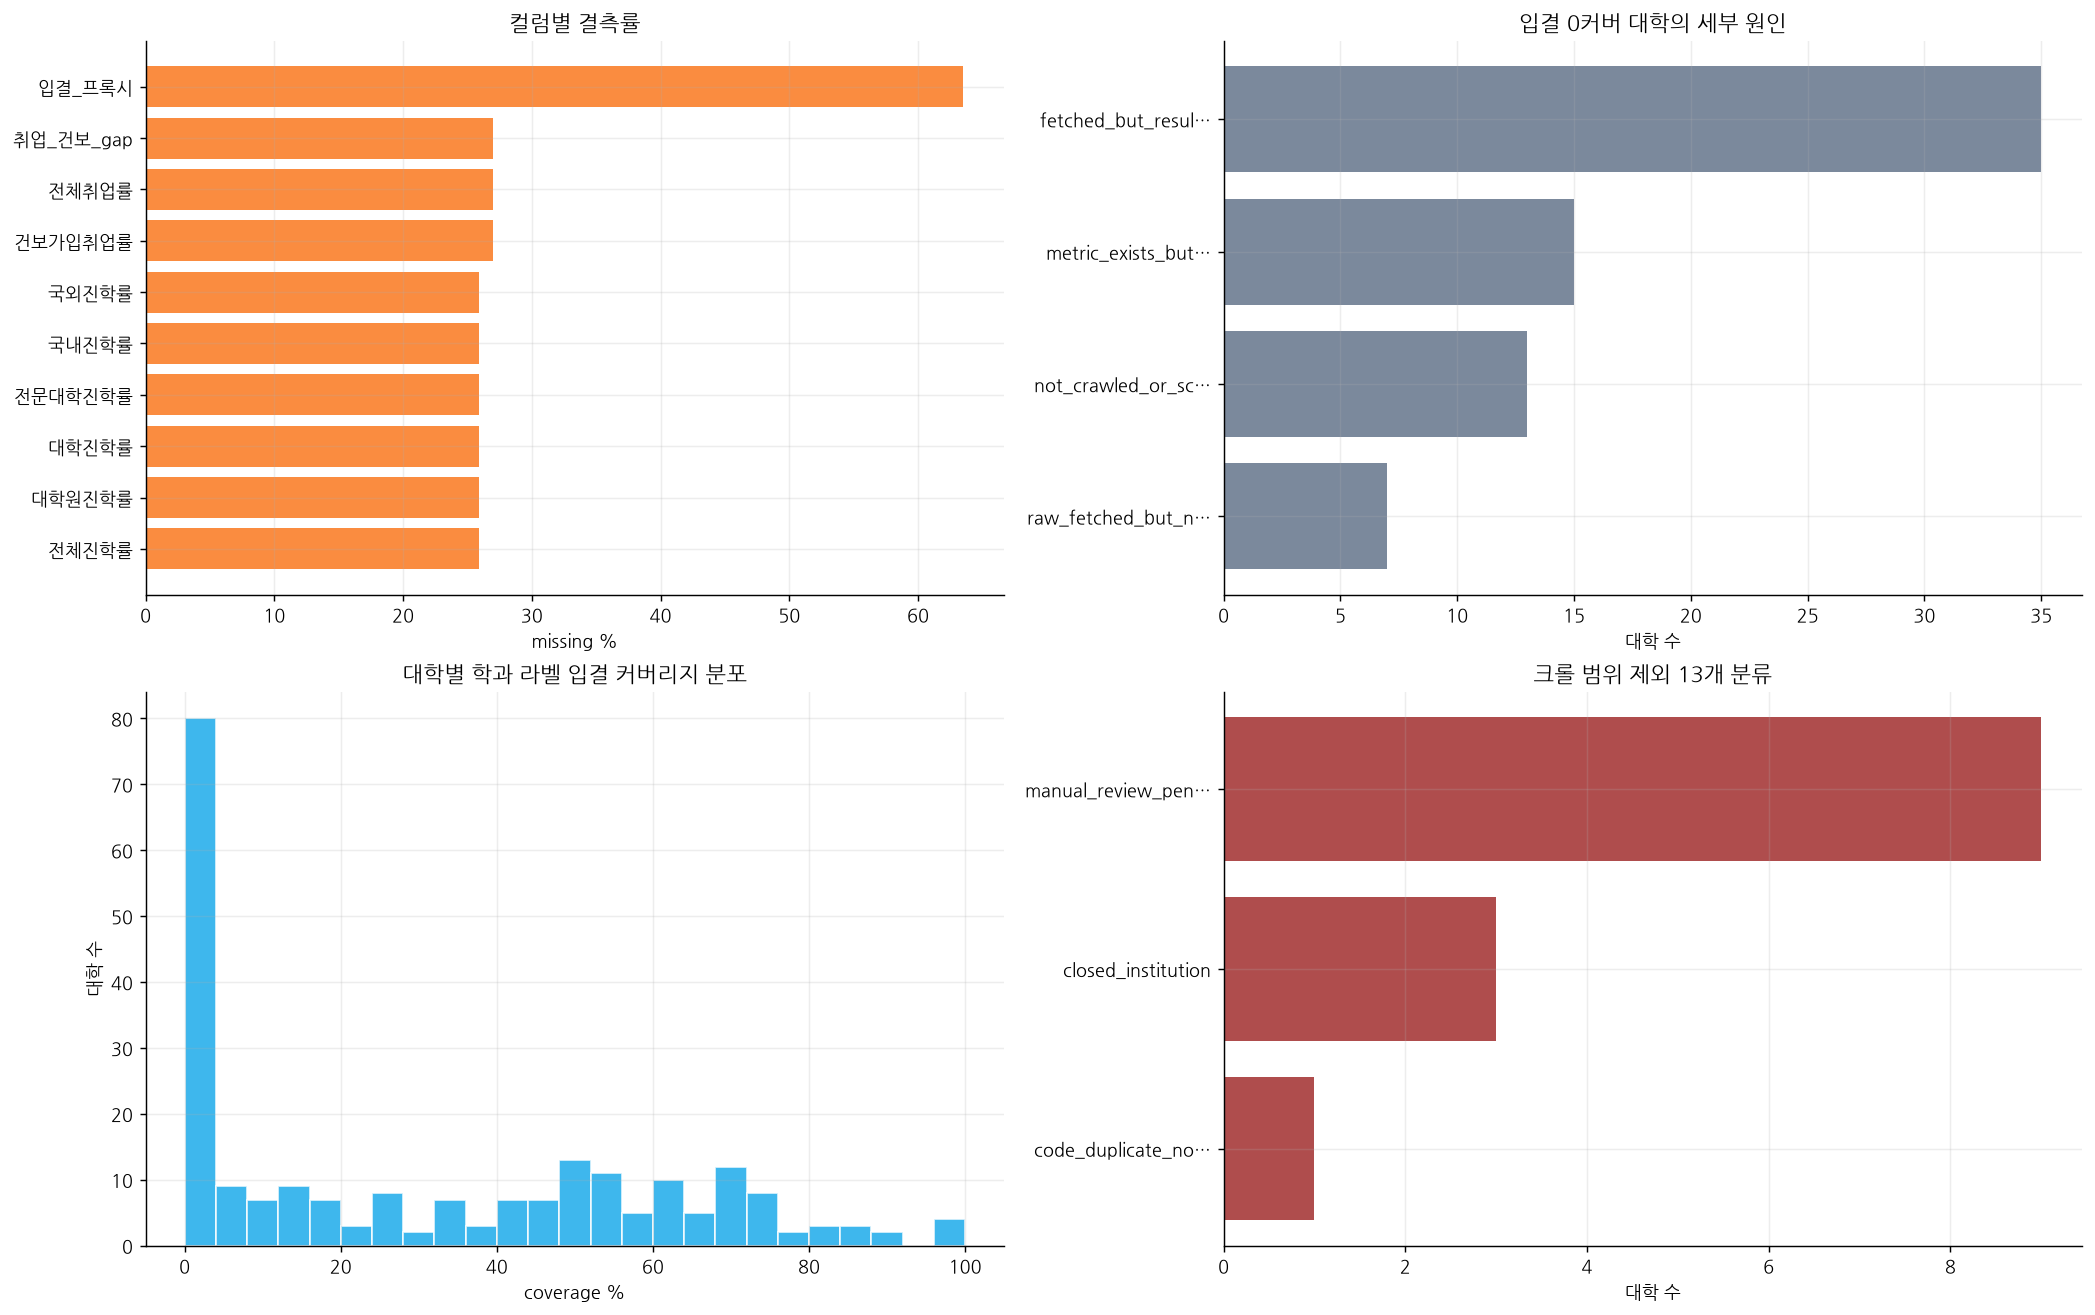

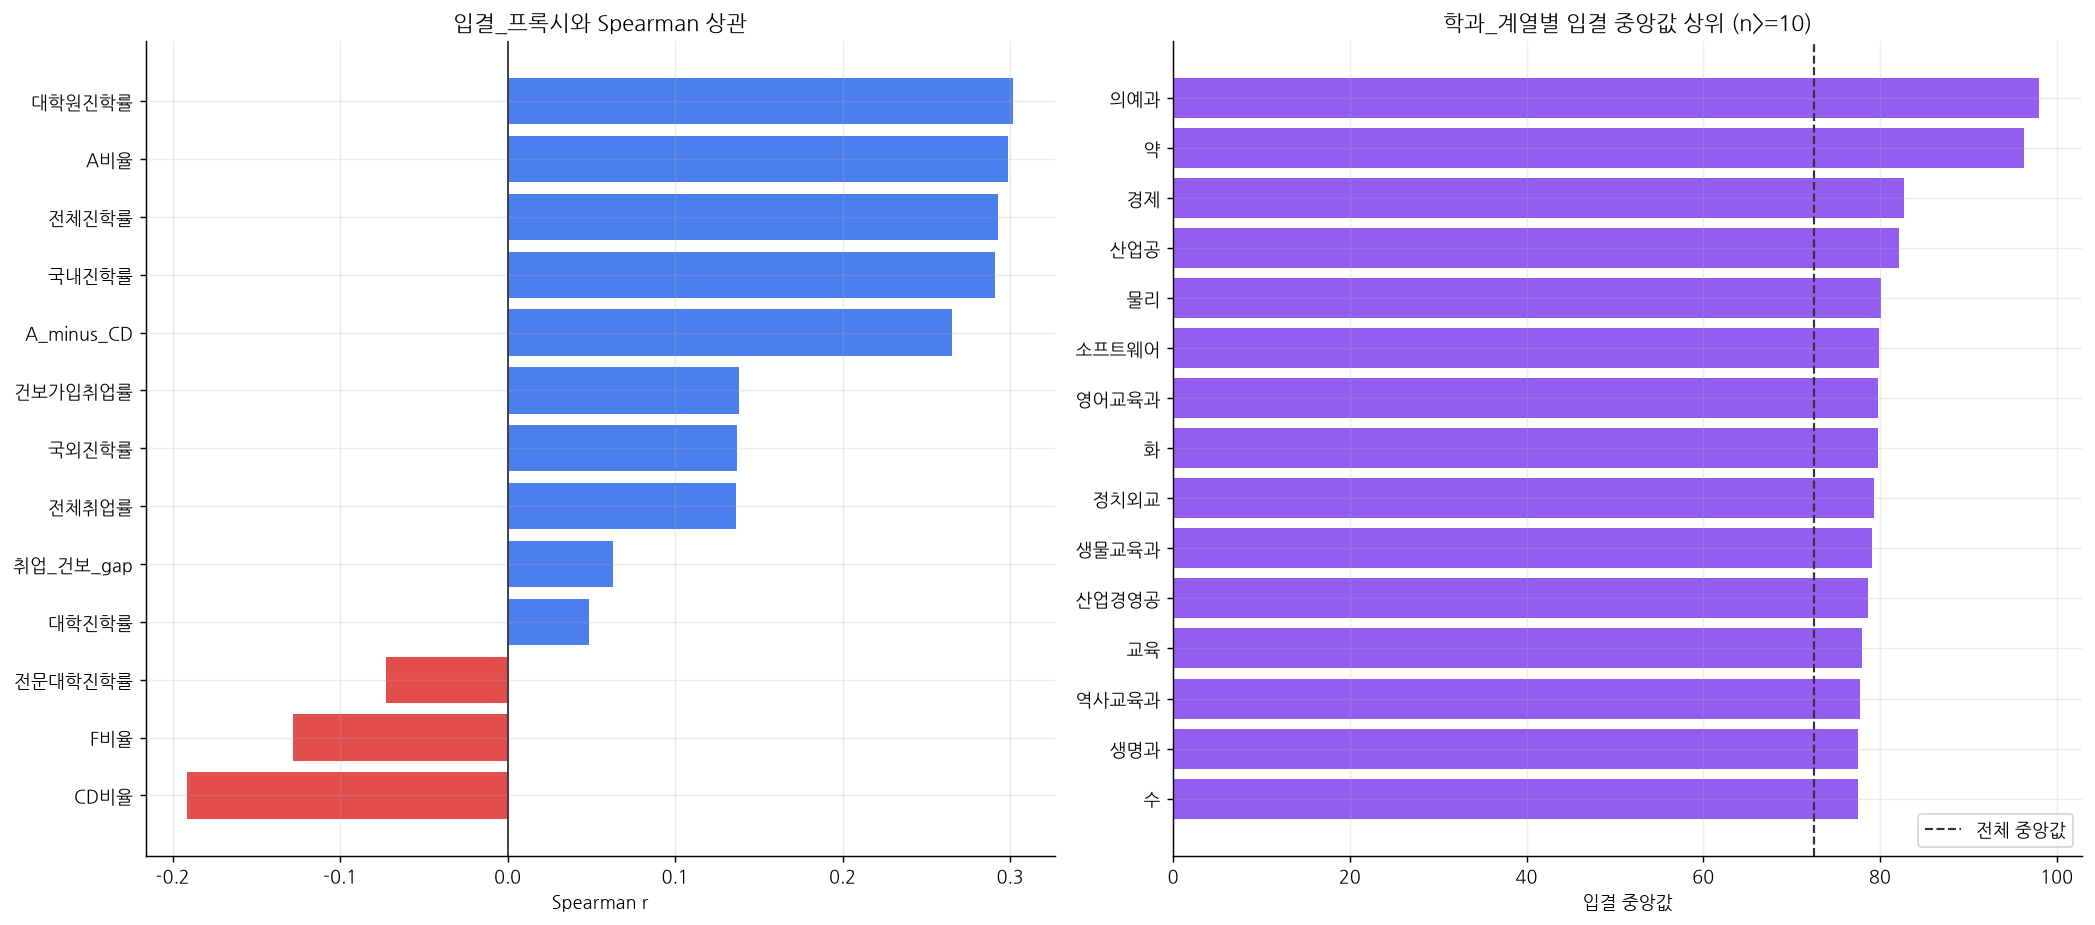

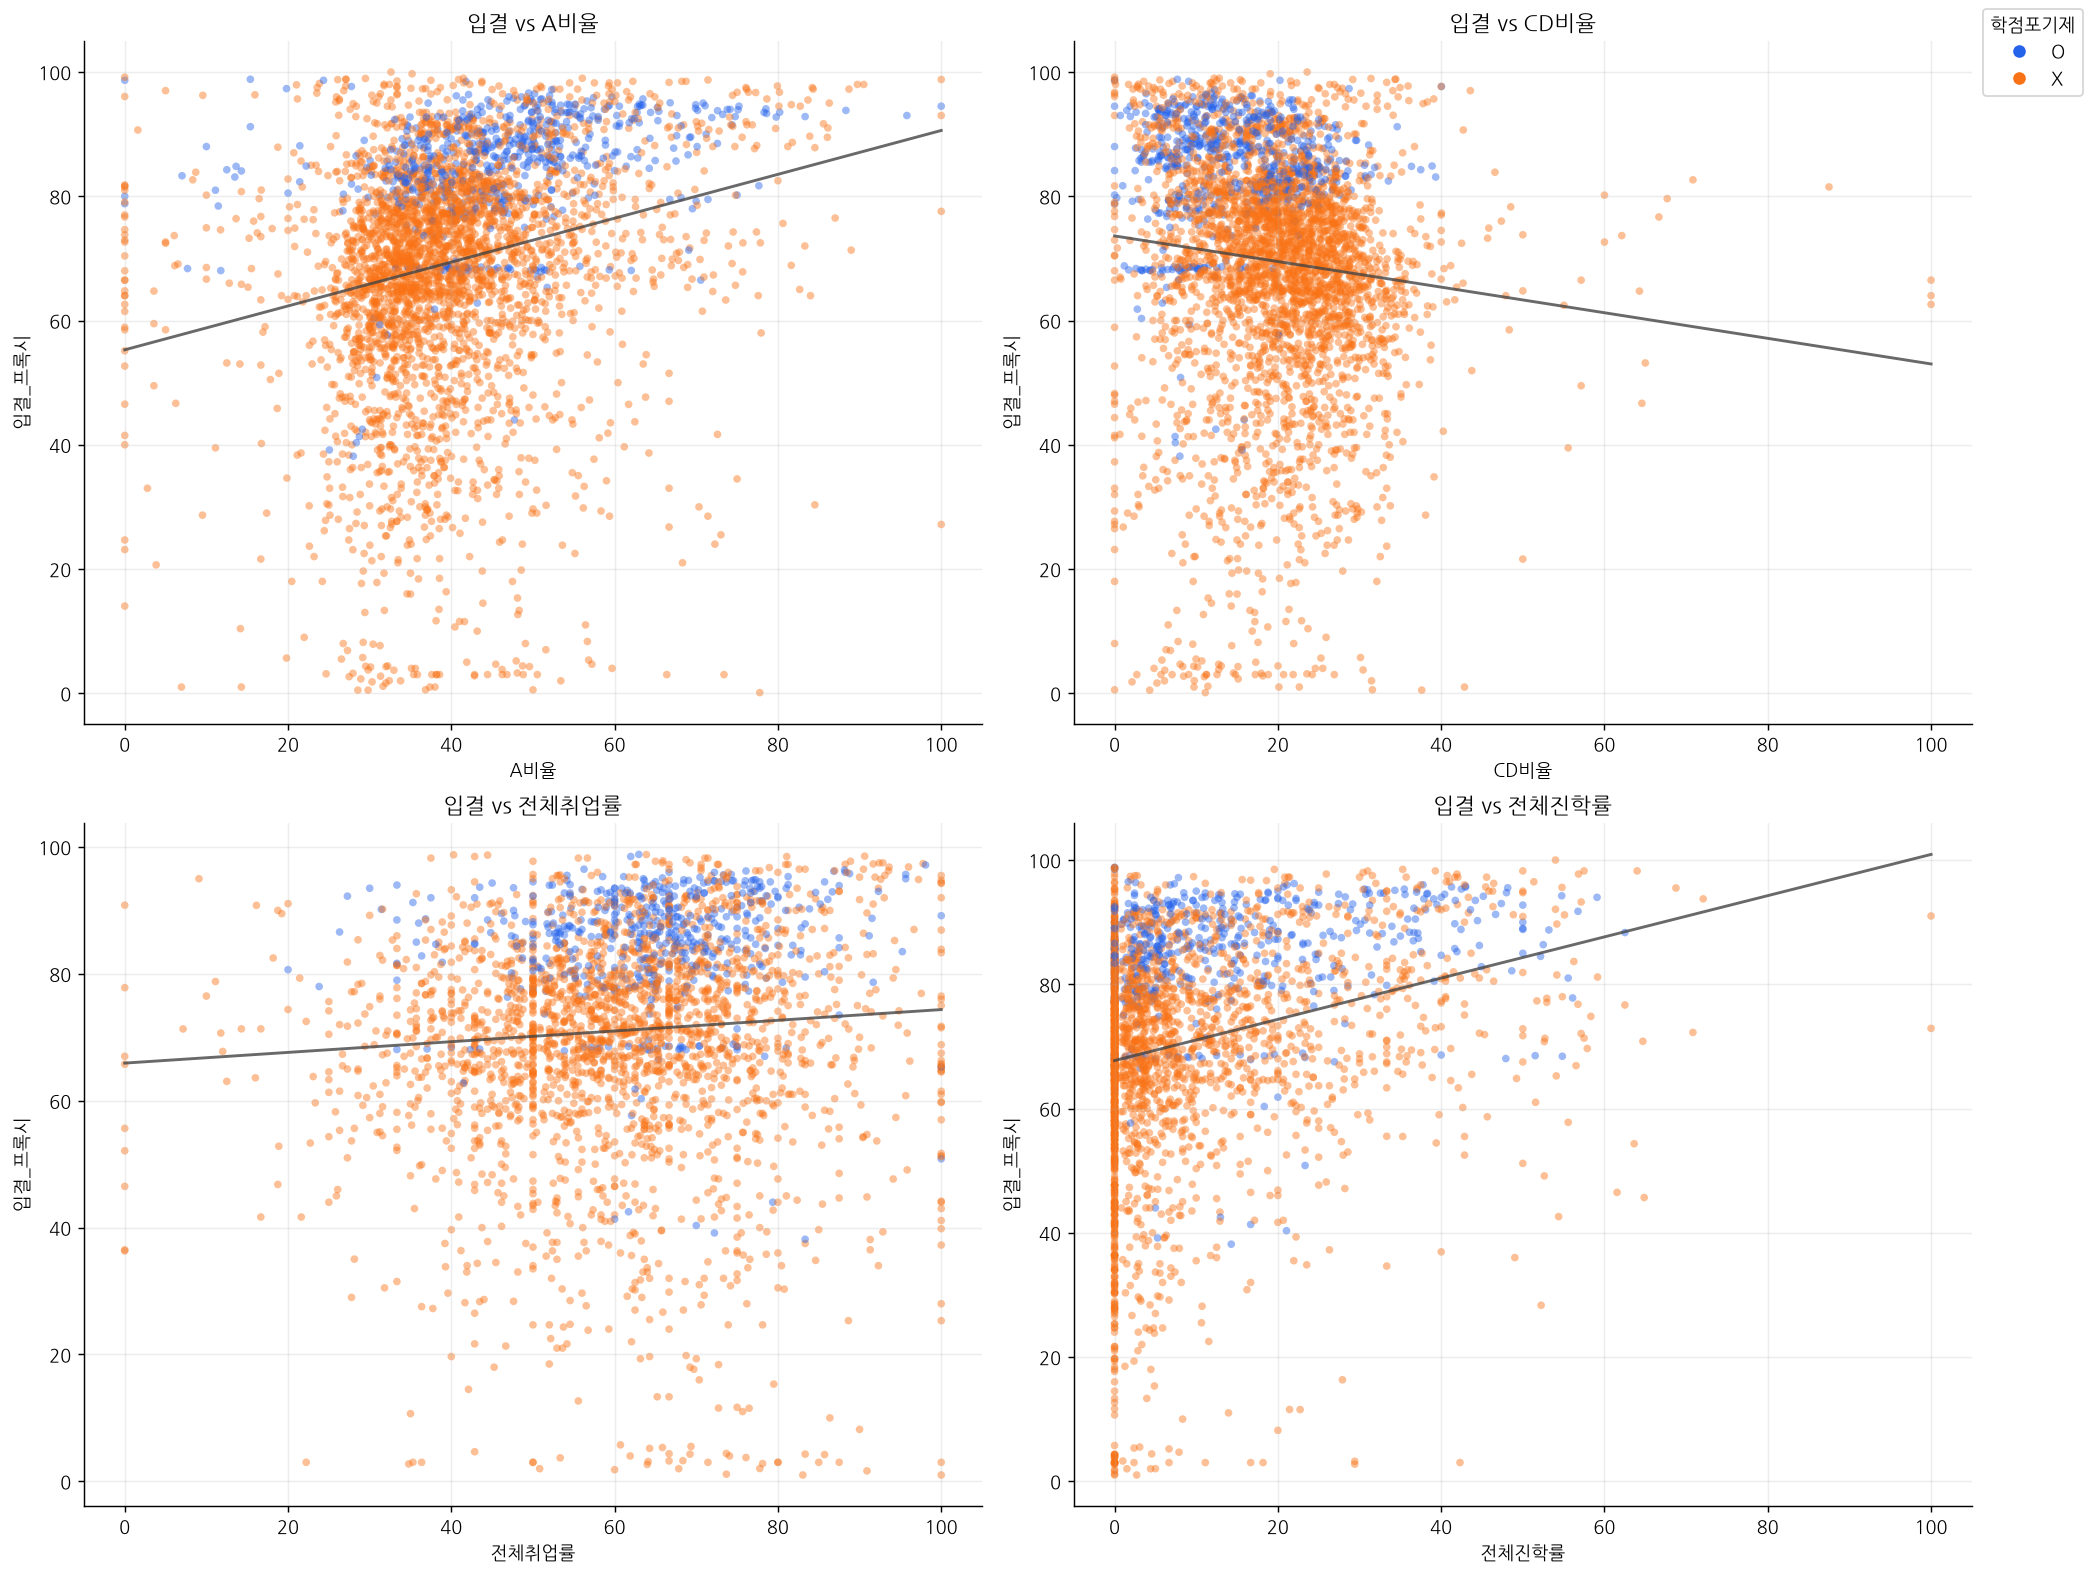

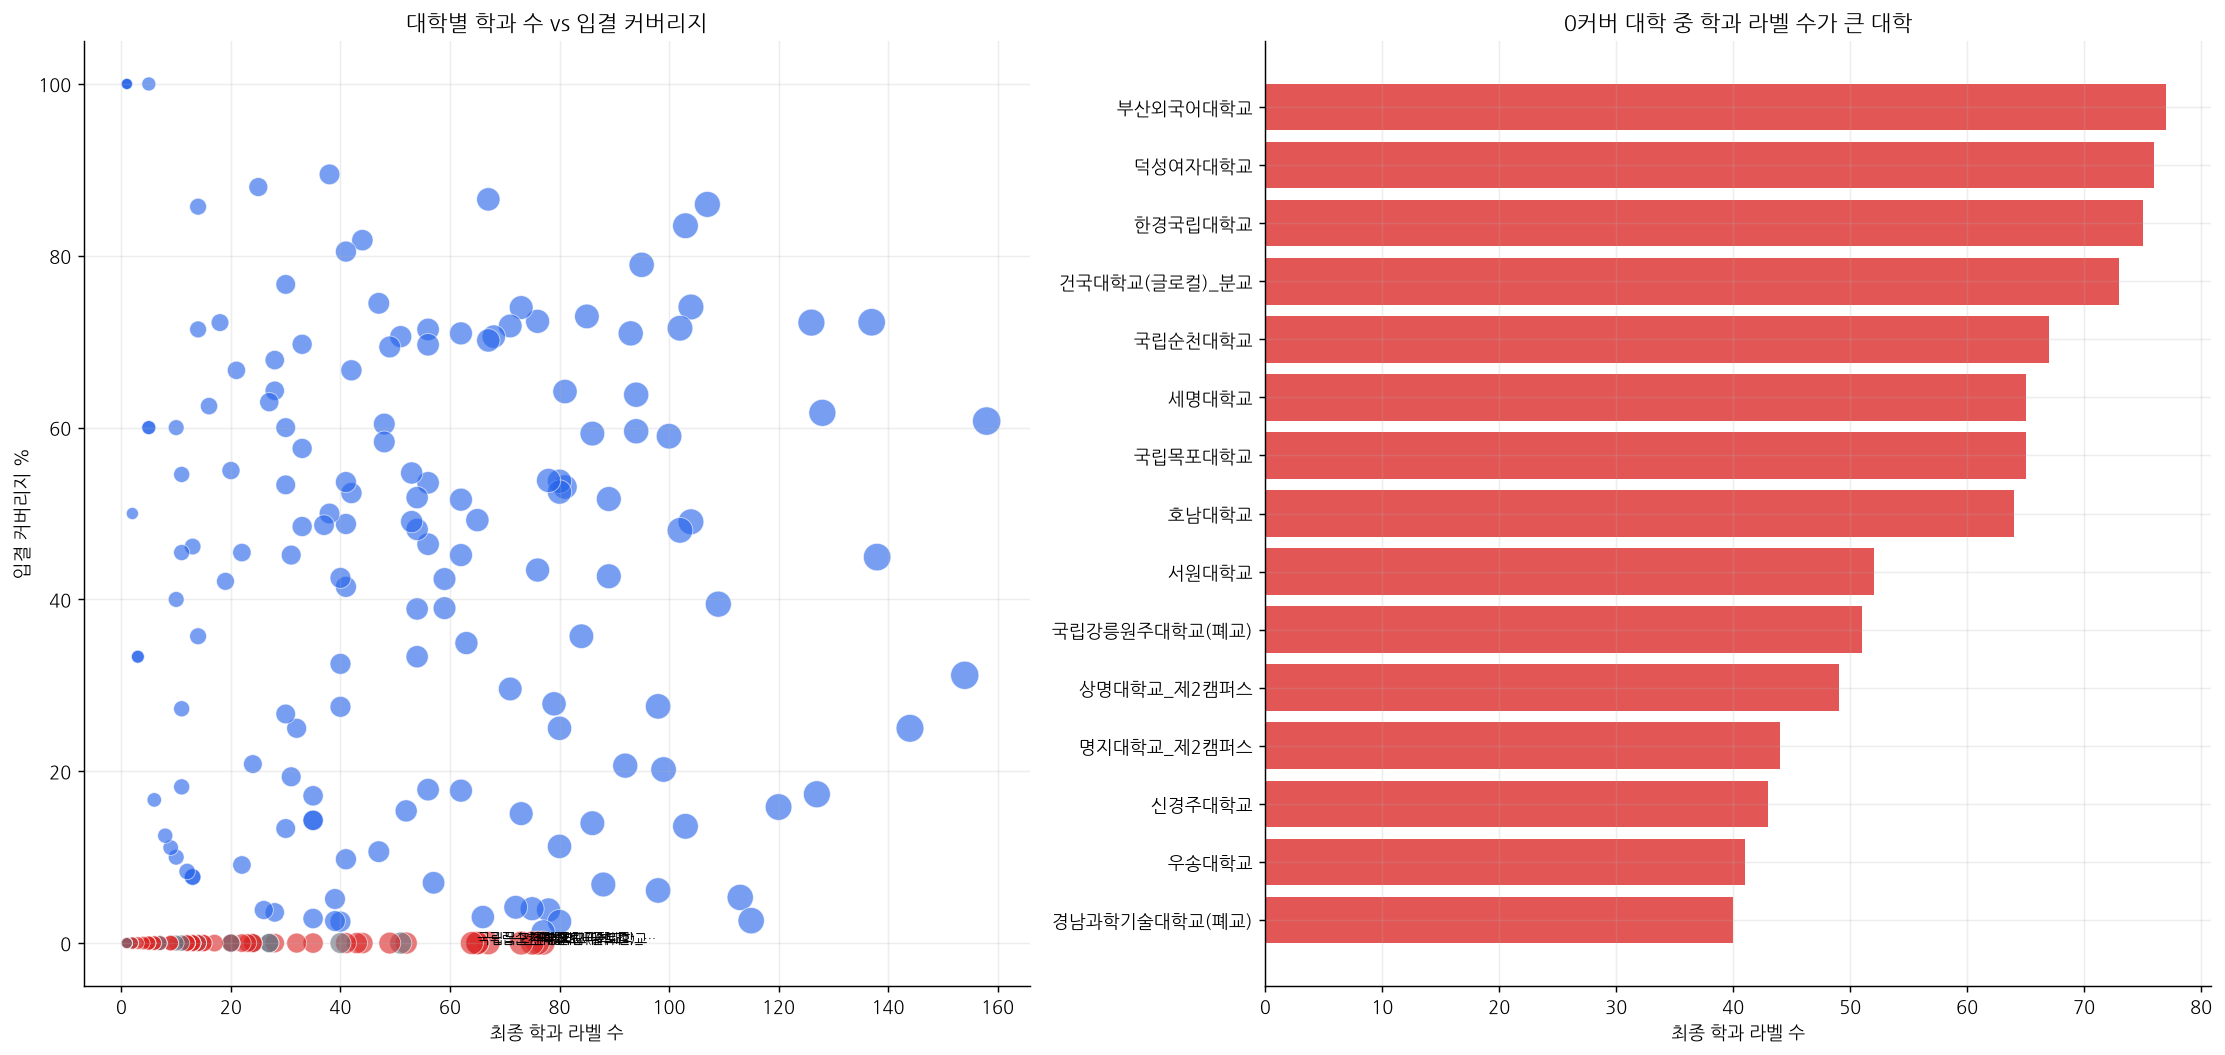

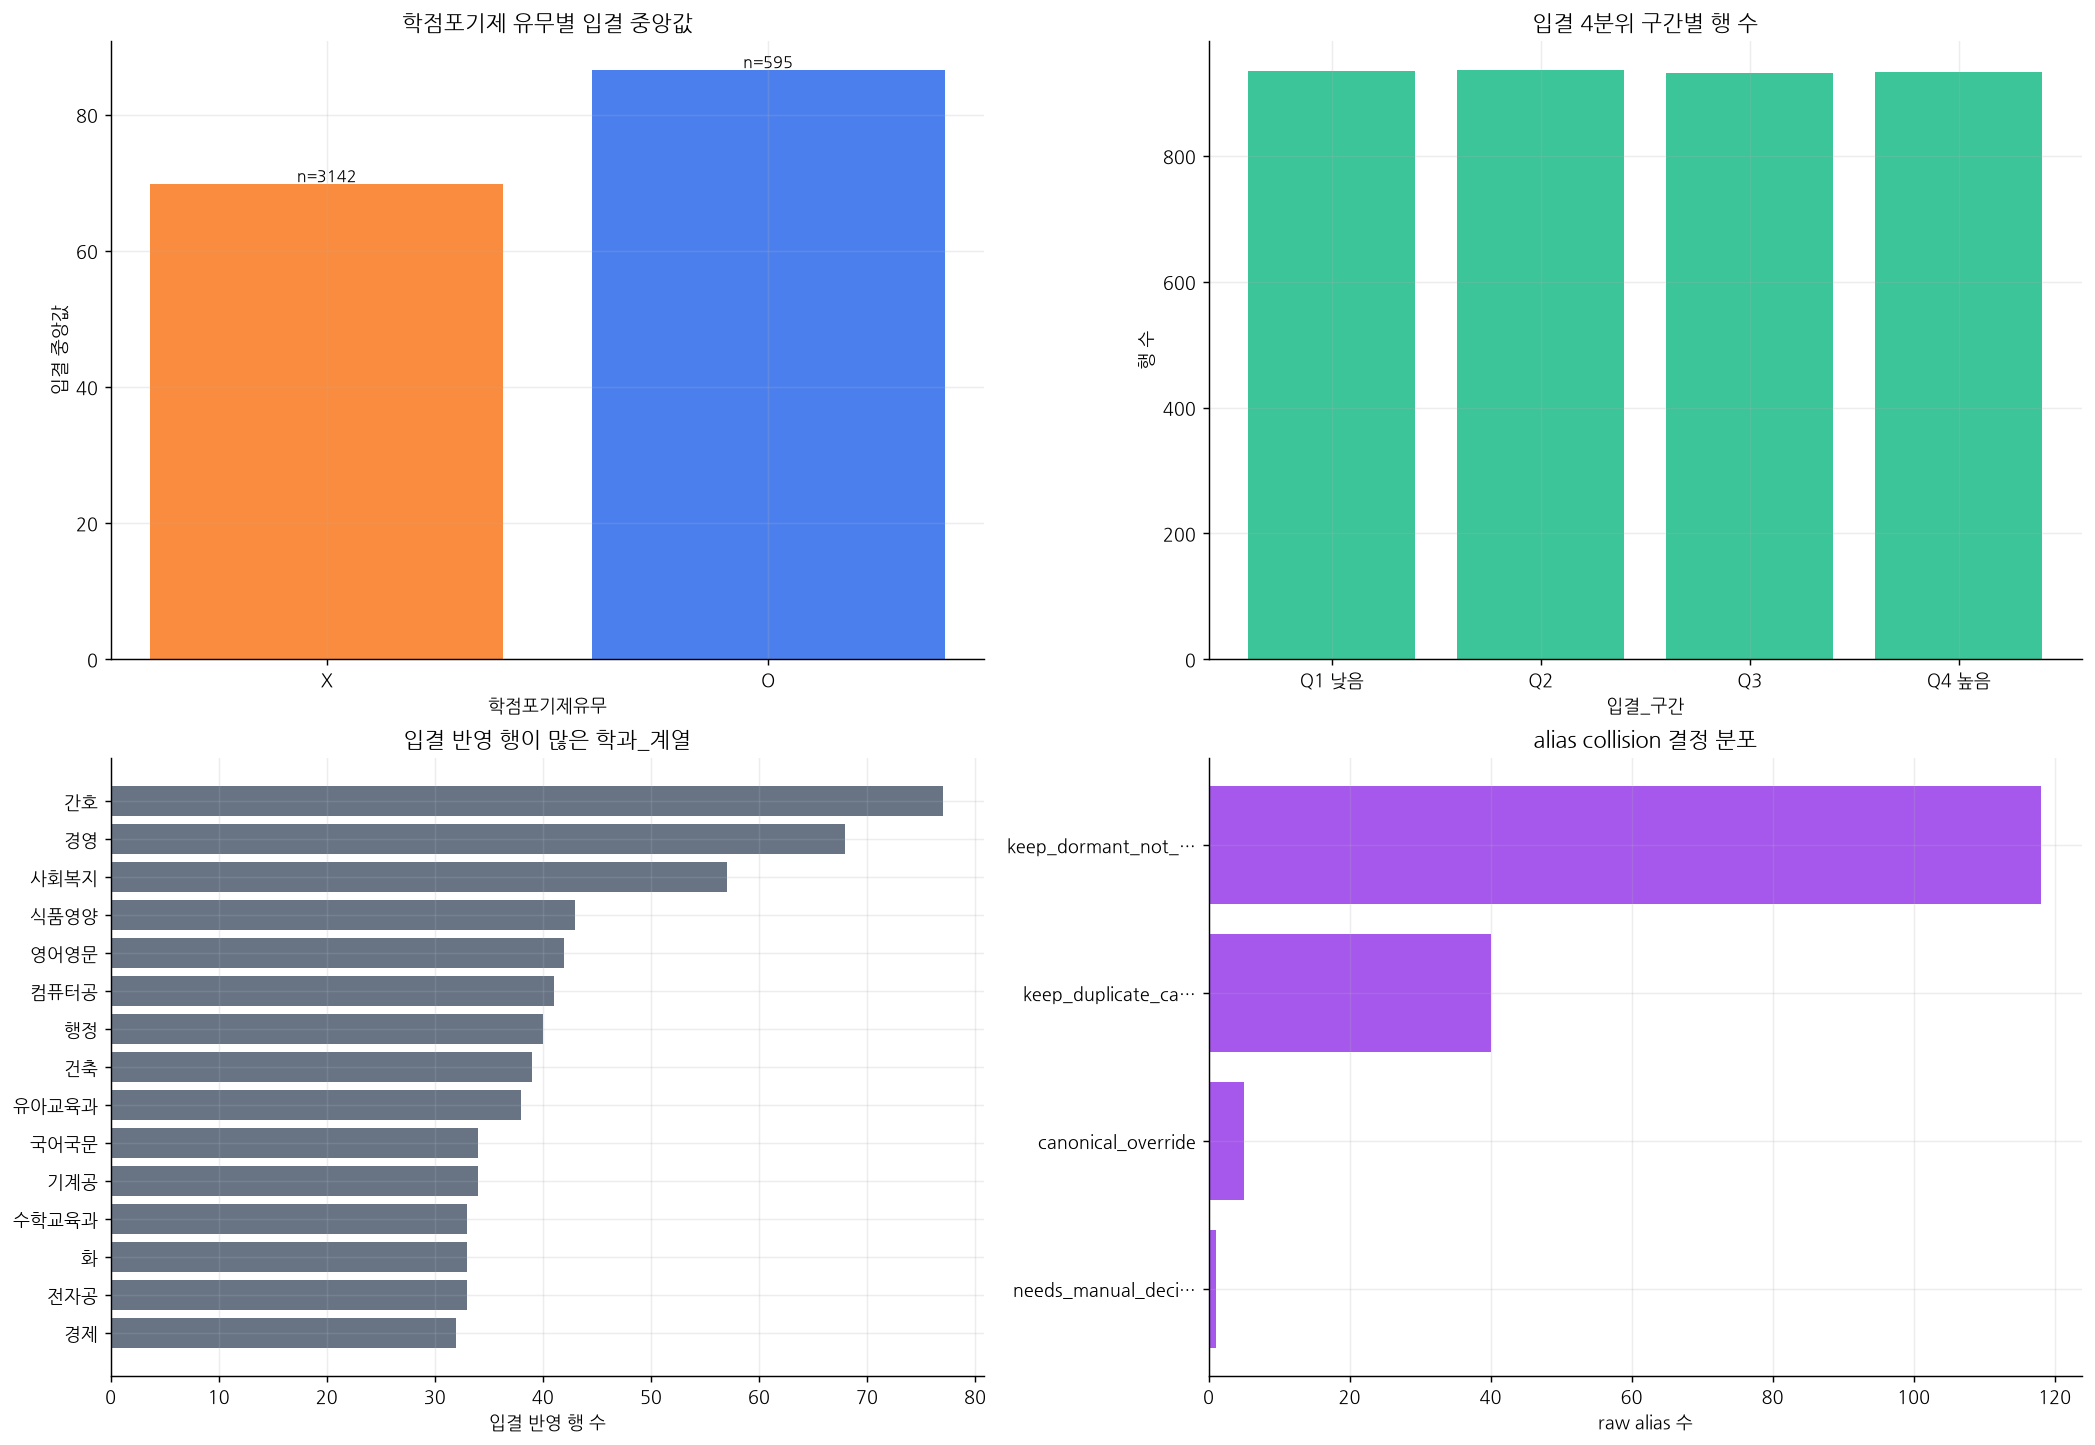


## 해석 스캐폴드

**Target 설계:**  
이 노트북의 target은 `입결_프록시`입니다. ADIGA 정시 70% cut 백분위 또는 대학별 환산점수/총점 정규화값을 최종 대학-학과_계열 키에 매칭한 연속형 변수입니다. 값은 0~100 범위이며, 대학 순위가 아니라 대학-학과 단위 입결 프록시입니다.

**관찰:**  
- 입결 점수는 3,737개 행, 157개 대학에 반영됐습니다.
- 결측은 6,505행(63.51%)입니다.
- 0커버 대학의 가장 큰 원인은 `fetched_but_result_tables_0` 35개입니다.
- 상관 상위 변수: 대학원진학률, A비율, 전체진학률
- 음의 상관이 큰 변수: CD비율, F비율, 전문대학진학률

**원인 가설:**  
입결이 높은 학과/대학에서는 A비율·취업률·진학률과의 관계가 단순 선형 하나로 설명되지 않습니다. 일부 변수는 대학/학과 구성효과와 결측 커버리지 영향을 함께 받으므로 산점도와 대학별 커버리지를 같이 봐야 합니다.

**제한:**  
입결 결측의 대부분은 아직 파서/학과매칭/ADIGA 범위 문제입니다. 특히 `fetched_but_result_tables_0`은 원 HTML을 가져왔지만 결과표 구조를 못 잡은 케이스라, 통계적 대체보다 파서 개선이 먼저입니다.

**결론:**  
현재 최종본은 분석용으로 사용 가능합니다. 다만 입결을 종속변수로 모델링할 때는 `입결_프록시.notna()` 행만 사용하고, 결측 자체가 무작위가 아니라 크롤/파싱/매칭 과정에서 생긴 구조적 결측이라는 점을 분석 제한으로 명시해야 합니다.


saved_dir= /home/sieg/projects-wsl/SBS_dataScience/workbook/p2/p2_2/final/eda/P2_G1_admission_visual_eda
00_overview.csv 521
01_missing_profile.csv 771
02_numeric_descriptive_stats.csv 1883
03_correlations_with_admission.csv 1092
04_school_coverage_summary.csv 46865
05_department_signal.csv 136853
06_policy_group_summary.csv 346
07_zero_coverage_reasons.csv 399
08_alias_collision_decisions.csv 40990
09_scope_exclusion.csv 1859
fig01_admission_distribution.png 172888
fig02_missing_and_coverage.png 153136
fig03_feature_signal.png 131258
fig04_admission_scatter.png 1521283
fig05_university_coverage_map.png 283306
fig06_department_policy_diagnostics.png 157945


In [1]:

from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)

BASE_DIR = Path("/home/sieg/projects-wsl/SBS_dataScience/workbook/p2/p2_2")
FINAL_PATH = BASE_DIR / "final/data/P2_G1_concat.csv"
COVERAGE_PATH = BASE_DIR / "final/admission/P2_admission_coverage_by_university_v3.csv"
COLLISION_DECISION_PATH = BASE_DIR / "final/admission/P2_admission_alias_collision_decisions_v3.csv"
SCOPE_EXCLUSION_PATH = BASE_DIR / "data/crawl_2024_admission_full/00_scope_exclusion_2024_full.csv"
OUT_DIR = BASE_DIR / "final/eda/P2_G1_admission_visual_eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def configure_korean_font() -> str:
    preferred = ["NanumGothic", "Noto Sans CJK KR", "Noto Sans KR", "Malgun Gothic", "AppleGothic"]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in preferred:
        if name in available:
            plt.rcParams["font.family"] = name
            plt.rcParams["axes.unicode_minus"] = False
            return name
    plt.rcParams["axes.unicode_minus"] = False
    return "DejaVu Sans"


FONT_USED = configure_korean_font()
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def save_csv(df: pd.DataFrame, name: str) -> Path:
    path = OUT_DIR / name
    df.to_csv(path, index=False, encoding="utf-8-sig")
    return path


def save_fig(fig: plt.Figure, name: str) -> Path:
    path = OUT_DIR / name
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    return path


def add_fit_line(ax, x: pd.Series, y: pd.Series, color: str = "#444444") -> None:
    ok = x.notna() & y.notna()
    if ok.sum() < 8 or x[ok].nunique() < 2:
        return
    coef = np.polyfit(x[ok], y[ok], deg=1)
    xs = np.linspace(float(x[ok].min()), float(x[ok].max()), 100)
    ax.plot(xs, coef[0] * xs + coef[1], color=color, linewidth=1.6, alpha=0.8)


def shorten(value: object, n: int = 18) -> str:
    text = str(value)
    return text if len(text) <= n else text[: n - 1] + "…"


df = pd.read_csv(FINAL_PATH, low_memory=False)
coverage = pd.read_csv(COVERAGE_PATH, low_memory=False)
collision_decisions = pd.read_csv(COLLISION_DECISION_PATH, low_memory=False)
scope_exclusion = pd.read_csv(SCOPE_EXCLUSION_PATH, low_memory=False)
source_shape = df.shape

numeric_cols = [
    "입결_프록시", "A비율", "CD비율", "F비율", "전체취업률", "건보가입취업률",
    "전체진학률", "전문대학진학률", "대학진학률", "대학원진학률", "국내진학률", "국외진학률",
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["입결_존재"] = df["입결_프록시"].notna()
df["A_minus_CD"] = df["A비율"] - df["CD비율"]
df["취업_건보_gap"] = df["전체취업률"] - df["건보가입취업률"]

analysis = df[df["입결_존재"]].copy()
analysis["입결_구간"] = pd.qcut(
    analysis["입결_프록시"], q=4, labels=["Q1 낮음", "Q2", "Q3", "Q4 높음"], duplicates="drop"
)

overview = pd.DataFrame([
    {"metric": "rows", "value": len(df), "note": "2024 대학-학과_계열 단위"},
    {"metric": "source_columns", "value": source_shape[1], "note": "최종 CSV 원본 컬럼 수"},
    {"metric": "working_columns", "value": df.shape[1], "note": "EDA 파생 컬럼 포함 작업 컬럼 수"},
    {"metric": "universities", "value": df["학교명"].nunique(), "note": "전체 대학 수"},
    {"metric": "department_labels", "value": df["학과_계열"].nunique(), "note": "정규화 학과 라벨 수"},
    {"metric": "admission_non_null", "value": int(df["입결_존재"].sum()), "note": "최종 CSV에 반영된 입결 점수 행"},
    {"metric": "admission_missing", "value": int(df["입결_프록시"].isna().sum()), "note": "입결 미반영 행"},
    {"metric": "admission_covered_universities", "value": analysis["학교명"].nunique(), "note": "입결 1개 이상 존재 대학"},
    {"metric": "duplicate_key_rows", "value": int(df.duplicated(["기준연도", "학교명", "학과_계열"]).sum()), "note": "중복 키 행"},
    {"metric": "font_used", "value": FONT_USED, "note": "matplotlib 한글 폰트"},
])

missing_profile = (
    df.isna().sum()
    .rename("missing_n")
    .reset_index()
    .rename(columns={"index": "column"})
)
missing_profile["missing_pct"] = missing_profile["missing_n"] / len(df) * 100
missing_profile["dtype"] = [str(df[col].dtype) for col in missing_profile["column"]]

numeric_stats = df[numeric_cols + ["A_minus_CD", "취업_건보_gap"]].describe(percentiles=[.05, .25, .5, .75, .95]).T.reset_index().rename(columns={"index": "column"})

corr_rows = []
feature_cols = [c for c in numeric_cols if c != "입결_프록시"] + ["A_minus_CD", "취업_건보_gap"]
for col in feature_cols:
    sub = df[["입결_프록시", col]].dropna()
    corr_rows.append({
        "feature": col,
        "n_pair": len(sub),
        "pearson": sub["입결_프록시"].corr(sub[col], method="pearson") if len(sub) >= 3 else np.nan,
        "spearman": sub["입결_프록시"].corr(sub[col], method="spearman") if len(sub) >= 3 else np.nan,
    })
correlations = pd.DataFrame(corr_rows)
correlations["abs_spearman"] = correlations["spearman"].abs()
correlations = correlations.sort_values("abs_spearman", ascending=False)

school_summary = (
    df.groupby("학교명", dropna=False)
    .agg(
        rows=("학과_계열", "size"),
        admission_n=("입결_존재", "sum"),
        admission_mean=("입결_프록시", "mean"),
        admission_median=("입결_프록시", "median"),
        A_mean=("A비율", "mean"),
        CD_mean=("CD비율", "mean"),
        F_mean=("F비율", "mean"),
        employment_mean=("전체취업률", "mean"),
        advancement_mean=("전체진학률", "mean"),
    )
    .reset_index()
)
school_summary["admission_row_coverage_pct"] = school_summary["admission_n"] / school_summary["rows"] * 100
school_summary = school_summary.merge(
    coverage[["학교명", "final_grade_department_labels", "final_admission_department_labels", "admission_label_coverage_pct", "zero_coverage_major_reason", "zero_coverage_detail_reason"]],
    on="학교명",
    how="left",
)

department_signal = (
    analysis.groupby("학과_계열", dropna=False)
    .agg(
        n=("입결_프록시", "size"),
        universities=("학교명", "nunique"),
        admission_median=("입결_프록시", "median"),
        admission_mean=("입결_프록시", "mean"),
        A_median=("A비율", "median"),
        CD_median=("CD비율", "median"),
        employment_median=("전체취업률", "median"),
    )
    .reset_index()
)
department_signal["lift_vs_overall_median"] = department_signal["admission_median"] - analysis["입결_프록시"].median()
department_signal = department_signal.sort_values(["admission_median", "n"], ascending=[False, False])

policy_summary = (
    df.groupby("학점포기제유무", dropna=False)
    .agg(
        rows=("학과_계열", "size"),
        admission_n=("입결_존재", "sum"),
        admission_median=("입결_프록시", "median"),
        admission_mean=("입결_프록시", "mean"),
        A_mean=("A비율", "mean"),
        CD_mean=("CD비율", "mean"),
        employment_mean=("전체취업률", "mean"),
    )
    .reset_index()
)
policy_summary["admission_coverage_pct"] = policy_summary["admission_n"] / policy_summary["rows"] * 100

zero_reason = (
    coverage[coverage["final_admission_department_labels"].eq(0)]
    .groupby(["zero_coverage_major_reason", "zero_coverage_detail_reason"], dropna=False)
    .agg(
        universities=("학교명", "size"),
        grade_labels=("final_grade_department_labels", "sum"),
        raw_rows=("raw_rows", "sum"),
        raw_metric_nonnull=("raw_metric_nonnull", "sum"),
    )
    .reset_index()
)

save_csv(overview, "00_overview.csv")
save_csv(missing_profile, "01_missing_profile.csv")
save_csv(numeric_stats, "02_numeric_descriptive_stats.csv")
save_csv(correlations, "03_correlations_with_admission.csv")
save_csv(school_summary.sort_values("admission_row_coverage_pct", ascending=False), "04_school_coverage_summary.csv")
save_csv(department_signal, "05_department_signal.csv")
save_csv(policy_summary, "06_policy_group_summary.csv")
save_csv(zero_reason, "07_zero_coverage_reasons.csv")
save_csv(collision_decisions, "08_alias_collision_decisions.csv")
save_csv(scope_exclusion, "09_scope_exclusion.csv")

display(Markdown(f"""
## P2 G1 입결 반영 EDA 실행 요약

- 분석 파일: `{FINAL_PATH}`
- 최종 CSV 원본 행/열: `{source_shape[0]:,}` x `{source_shape[1]:,}`
- EDA 작업 행/열: `{df.shape[0]:,}` x `{df.shape[1]:,}` (`입결_존재`, `A_minus_CD`, `취업_건보_gap` 파생)
- 입결 반영 행: `{int(df["입결_존재"].sum()):,}` / `{len(df):,}` (`{df["입결_존재"].mean()*100:.2f}%`)
- 입결 커버 대학: `{analysis["학교명"].nunique():,}` / `{df["학교명"].nunique():,}`
- 입결 미반영 행: `{int(df["입결_프록시"].isna().sum()):,}` (`{df["입결_프록시"].isna().mean()*100:.2f}%`)
- 중복 키: `{int(df.duplicated(["기준연도", "학교명", "학과_계열"]).sum())}`건
- 한글 폰트: `{FONT_USED}`
"""))

display(overview)
display(Markdown("### 주요 컬럼 결측"))
display(missing_profile[missing_profile["column"].isin(["입결_프록시", "전체취업률", "건보가입취업률", "전체진학률", "학점포기제유무"])])
display(Markdown("### 입결과 숫자형 변수의 상관"))
display(correlations)
display(Markdown("### 0커버 대학 원인"))
display(zero_reason)


# Figure 01: target profile
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
ax = axes[0, 0]
ax.hist(analysis["입결_프록시"], bins=32, color="#3B82F6", alpha=0.82, edgecolor="white")
median = analysis["입결_프록시"].median()
ax.axvline(median, color="#DC2626", linestyle="--", linewidth=1.6, label=f"median={median:.2f}")
ax.set_title("입결_프록시 분포")
ax.set_xlabel("70% cut 백분위/정규화 점수")
ax.set_ylabel("대학-학과 수")
ax.legend()

ax = axes[0, 1]
quant = analysis["입결_프록시"].quantile([.05, .25, .5, .75, .95]).rename("입결_프록시").reset_index()
quant["index"] = quant["index"].map(lambda x: f"p{int(x*100)}")
ax.axis("off")
table = ax.table(cellText=np.round(quant["입결_프록시"].to_numpy()[:, None], 2), rowLabels=quant["index"], colLabels=["value"], loc="center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.1, 1.45)
ax.set_title("입결 분위수")

ax = axes[1, 0]
policy_data = [analysis.loc[analysis["학점포기제유무"].eq(v), "입결_프록시"].dropna() for v in sorted(analysis["학점포기제유무"].dropna().unique())]
policy_labels = sorted(analysis["학점포기제유무"].dropna().unique())
try:
    ax.boxplot(policy_data, tick_labels=policy_labels, patch_artist=True)
except TypeError:
    ax.boxplot(policy_data, labels=policy_labels, patch_artist=True)
ax.set_title("학점포기제 유무별 입결 분포")
ax.set_xlabel("학점포기제유무")
ax.set_ylabel("입결_프록시")

ax = axes[1, 1]
top_schools = school_summary[school_summary["admission_n"].ge(5)].nlargest(12, "admission_median").sort_values("admission_median")
ax.barh(top_schools["학교명"].map(shorten), top_schools["admission_median"], color="#16A34A", alpha=0.85)
ax.set_title("입결 중앙값 상위 대학 (입결 n>=5)")
ax.set_xlabel("입결 중앙값")
save_fig(fig, "fig01_admission_distribution.png")
plt.show()


# Figure 02: missing and coverage
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
ax = axes[0, 0]
miss_view = missing_profile[missing_profile["missing_n"].gt(0)].sort_values("missing_pct", ascending=True)
ax.barh(miss_view["column"], miss_view["missing_pct"], color="#F97316", alpha=0.82)
ax.set_title("컬럼별 결측률")
ax.set_xlabel("missing %")

ax = axes[0, 1]
detail_counts = coverage.loc[coverage["final_admission_department_labels"].eq(0), "zero_coverage_detail_reason"].value_counts().sort_values()
ax.barh(detail_counts.index.map(shorten), detail_counts.values, color="#64748B", alpha=0.85)
ax.set_title("입결 0커버 대학의 세부 원인")
ax.set_xlabel("대학 수")

ax = axes[1, 0]
ax.hist(coverage["admission_label_coverage_pct"].fillna(0), bins=25, color="#0EA5E9", alpha=0.80, edgecolor="white")
ax.set_title("대학별 학과 라벨 입결 커버리지 분포")
ax.set_xlabel("coverage %")
ax.set_ylabel("대학 수")

ax = axes[1, 1]
scope_counts = scope_exclusion["exclusion_category"].value_counts().sort_values()
ax.barh(scope_counts.index.map(shorten), scope_counts.values, color="#991B1B", alpha=0.78)
ax.set_title("크롤 범위 제외 13개 분류")
ax.set_xlabel("대학 수")
save_fig(fig, "fig02_missing_and_coverage.png")
plt.show()


# Figure 03: feature signal
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
ax = axes[0]
corr_view = correlations.dropna(subset=["spearman"]).sort_values("spearman")
colors = np.where(corr_view["spearman"].ge(0), "#2563EB", "#DC2626")
ax.barh(corr_view["feature"], corr_view["spearman"], color=colors, alpha=0.82)
ax.axvline(0, color="#333333", linewidth=1)
ax.set_title("입결_프록시와 Spearman 상관")
ax.set_xlabel("Spearman r")

ax = axes[1]
dept_view = department_signal[department_signal["n"].ge(10)].head(15).sort_values("admission_median")
ax.barh(dept_view["학과_계열"].map(shorten), dept_view["admission_median"], color="#7C3AED", alpha=0.82)
ax.axvline(analysis["입결_프록시"].median(), color="#333333", linestyle="--", linewidth=1.2, label="전체 중앙값")
ax.set_title("학과_계열별 입결 중앙값 상위 (n>=10)")
ax.set_xlabel("입결 중앙값")
ax.legend(loc="lower right")
save_fig(fig, "fig03_feature_signal.png")
plt.show()


# Figure 04: scatter diagnostics
fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
scatter_specs = [
    ("A비율", "입결 vs A비율"),
    ("CD비율", "입결 vs CD비율"),
    ("전체취업률", "입결 vs 전체취업률"),
    ("전체진학률", "입결 vs 전체진학률"),
]
policy_color = analysis["학점포기제유무"].map({"O": "#2563EB", "X": "#F97316"}).fillna("#6B7280")
for ax, (xcol, title) in zip(axes.ravel(), scatter_specs):
    sub = analysis[[xcol, "입결_프록시", "학점포기제유무"]].dropna()
    ax.scatter(sub[xcol], sub["입결_프록시"], s=18, c=sub["학점포기제유무"].map({"O": "#2563EB", "X": "#F97316"}).fillna("#6B7280"), alpha=0.45, edgecolor="none")
    add_fit_line(ax, sub[xcol], sub["입결_프록시"])
    ax.set_title(title)
    ax.set_xlabel(xcol)
    ax.set_ylabel("입결_프록시")
handles = [
    plt.Line2D([0], [0], marker="o", color="w", label="O", markerfacecolor="#2563EB", markersize=8),
    plt.Line2D([0], [0], marker="o", color="w", label="X", markerfacecolor="#F97316", markersize=8),
]
fig.legend(handles=handles, title="학점포기제", loc="outside right upper")
save_fig(fig, "fig04_admission_scatter.png")
plt.show()


# Figure 05: university coverage map
fig, axes = plt.subplots(1, 2, figsize=(17, 8), constrained_layout=True)
ax = axes[0]
cov_plot = coverage.copy()
size = 20 + np.sqrt(cov_plot["final_grade_department_labels"].clip(lower=1)) * 18
colors = cov_plot["zero_coverage_major_reason"].map({
    "covered_or_partial": "#2563EB",
    "crawled_but_zero_coverage": "#DC2626",
    "not_crawled_or_scope_excluded": "#6B7280",
}).fillna("#2563EB")
ax.scatter(cov_plot["final_grade_department_labels"], cov_plot["admission_label_coverage_pct"].fillna(0), s=size, c=colors, alpha=0.62, edgecolor="white", linewidth=0.5)
ax.set_title("대학별 학과 수 vs 입결 커버리지")
ax.set_xlabel("최종 학과 라벨 수")
ax.set_ylabel("입결 커버리지 %")
for _, row in cov_plot[cov_plot["final_admission_department_labels"].eq(0)].nlargest(6, "final_grade_department_labels").iterrows():
    ax.annotate(shorten(row["학교명"], 12), (row["final_grade_department_labels"], row["admission_label_coverage_pct"] if pd.notna(row["admission_label_coverage_pct"]) else 0), fontsize=8)

ax = axes[1]
missing_univ = cov_plot[cov_plot["final_admission_department_labels"].eq(0)].nlargest(15, "final_grade_department_labels").sort_values("final_grade_department_labels")
ax.barh(missing_univ["학교명"].map(shorten), missing_univ["final_grade_department_labels"], color="#DC2626", alpha=0.78)
ax.set_title("0커버 대학 중 학과 라벨 수가 큰 대학")
ax.set_xlabel("최종 학과 라벨 수")
save_fig(fig, "fig05_university_coverage_map.png")
plt.show()


# Figure 06: group diagnostics
fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
ax = axes[0, 0]
policy_plot = policy_summary.sort_values("admission_median")
ax.bar(policy_plot["학점포기제유무"], policy_plot["admission_median"], color=["#F97316" if v == "X" else "#2563EB" for v in policy_plot["학점포기제유무"]], alpha=0.82)
for i, row in policy_plot.reset_index(drop=True).iterrows():
    ax.text(i, row["admission_median"], f"n={int(row['admission_n'])}", ha="center", va="bottom", fontsize=9)
ax.set_title("학점포기제 유무별 입결 중앙값")
ax.set_xlabel("학점포기제유무")
ax.set_ylabel("입결 중앙값")

ax = axes[0, 1]
quartile_counts = analysis["입결_구간"].value_counts().sort_index()
ax.bar(quartile_counts.index.astype(str), quartile_counts.values, color="#10B981", alpha=0.82)
ax.set_title("입결 4분위 구간별 행 수")
ax.set_xlabel("입결_구간")
ax.set_ylabel("행 수")

ax = axes[1, 0]
top_depts_by_n = department_signal.nlargest(15, "n").sort_values("n")
ax.barh(top_depts_by_n["학과_계열"].map(shorten), top_depts_by_n["n"], color="#475569", alpha=0.82)
ax.set_title("입결 반영 행이 많은 학과_계열")
ax.set_xlabel("입결 반영 행 수")

ax = axes[1, 1]
collision_counts = collision_decisions["decision"].value_counts().sort_values()
ax.barh(collision_counts.index.map(shorten), collision_counts.values, color="#9333EA", alpha=0.82)
ax.set_title("alias collision 결정 분포")
ax.set_xlabel("raw alias 수")
save_fig(fig, "fig06_department_policy_diagnostics.png")
plt.show()

top_corr = correlations.dropna(subset=["spearman"]).sort_values("spearman", ascending=False).head(3)
bottom_corr = correlations.dropna(subset=["spearman"]).sort_values("spearman").head(3)
zero_detail = coverage.loc[coverage["final_admission_department_labels"].eq(0), "zero_coverage_detail_reason"].value_counts()

interpretation = f"""
## 해석 스캐폴드

**Target 설계:**  
이 노트북의 target은 `입결_프록시`입니다. ADIGA 정시 70% cut 백분위 또는 대학별 환산점수/총점 정규화값을 최종 대학-학과_계열 키에 매칭한 연속형 변수입니다. 값은 0~100 범위이며, 대학 순위가 아니라 대학-학과 단위 입결 프록시입니다.

**관찰:**  
- 입결 점수는 {int(df["입결_존재"].sum()):,}개 행, {analysis["학교명"].nunique():,}개 대학에 반영됐습니다.
- 결측은 {int(df["입결_프록시"].isna().sum()):,}행({df["입결_프록시"].isna().mean()*100:.2f}%)입니다.
- 0커버 대학의 가장 큰 원인은 `{zero_detail.index[0]}` {int(zero_detail.iloc[0])}개입니다.
- 상관 상위 변수: {", ".join(top_corr["feature"].tolist())}
- 음의 상관이 큰 변수: {", ".join(bottom_corr["feature"].tolist())}

**원인 가설:**  
입결이 높은 학과/대학에서는 A비율·취업률·진학률과의 관계가 단순 선형 하나로 설명되지 않습니다. 일부 변수는 대학/학과 구성효과와 결측 커버리지 영향을 함께 받으므로 산점도와 대학별 커버리지를 같이 봐야 합니다.

**제한:**  
입결 결측의 대부분은 아직 파서/학과매칭/ADIGA 범위 문제입니다. 특히 `fetched_but_result_tables_0`은 원 HTML을 가져왔지만 결과표 구조를 못 잡은 케이스라, 통계적 대체보다 파서 개선이 먼저입니다.

**결론:**  
현재 최종본은 분석용으로 사용 가능합니다. 다만 입결을 종속변수로 모델링할 때는 `입결_프록시.notna()` 행만 사용하고, 결측 자체가 무작위가 아니라 크롤/파싱/매칭 과정에서 생긴 구조적 결측이라는 점을 분석 제한으로 명시해야 합니다.
"""
display(Markdown(interpretation))

print("saved_dir=", OUT_DIR)
for path in sorted(OUT_DIR.glob("*")):
    print(path.name, path.stat().st_size)


## 사용 방법

위 셀을 실행하면 `final/eda/P2_G1_admission_visual_eda/`에 CSV 감사표와 PNG 시각화가 저장된다. 노트북 출력의 해석 스캐폴드는 현재 최종 CSV 기준으로 자동 계산된다.